# Brazilian Port Lead Time — Safety Stock Application

Notebook 01 asked whether port stay can be predicted. Notebook 02 moved from point prediction to quantile estimates of lead-time uncertainty. This third notebook connects those estimates to a small supply-chain planning scenario:

port-stay prediction -> lead-time uncertainty -> planning lead-time policy -> safety stock -> working-capital proxy.

This is an **educational scenario analysis**, not an observed business result. The public dataset does not contain real SKU demand, purchase orders, inventory positions, item values, replenishment policies, holding costs, shortage costs, or complete end-to-end logistics lead time. The numbers below should not be interpreted as real inventory savings, real working-capital savings, or realized service-level improvements.

Links:

- Dataset: https://www.kaggle.com/datasets/tiagoalberione/brazilian-port-lead-time-2023-2025
- GitHub repository: https://github.com/tiagoalberione/port-leadtime-prediction

## 1. Imports and Configuration

The notebook uses the same public modeling ingredients as Notebook 02: pandas, NumPy, matplotlib, and scikit-learn. The random state and quantile-model parameters are fixed; there is no tuning in this notebook.

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_pinball_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder


RANDOM_STATE = 42
TARGET = "t_total_port_stay_h"
DATE_COL = "arrival_port_ts"
ID_COL = "port_call_id"
SPLIT_COL = "split"
BASE_COLUMNS = [ID_COL, DATE_COL, TARGET, SPLIT_COL]
MODEL_FILE = "brazilian_port_calls_model_ready_2023_2025.csv"
SPLIT_ORDER = ["train", "validation", "calibration", "final_test"]
DEVELOPMENT_SPLITS = ["train", "validation", "calibration"]
QUANTILES = {"P50": 0.50, "P90": 0.90, "P95": 0.95}
MIN_SEGMENT_ROWS = 30

NOTEBOOK_START = time.perf_counter()

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
plt.rcParams.update(
    {
        "figure.figsize": (9, 5),
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)

## 2. Load and Validate the Public Data

The public Kaggle dataset exposes one runtime file: `brazilian_port_calls_model_ready_2023_2025.csv`. The helper searches under `/kaggle/input` first and falls back to the local generated dataset when the notebook is run from the GitHub repository.

In [2]:
def find_input_file(filename, local_relative_dirs):
    candidates = []
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates.extend(sorted(kaggle_input.rglob(filename)))

    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        for relative_dir in local_relative_dirs:
            candidates.append(base / relative_dir / filename)

    for candidate in candidates:
        if candidate.exists():
            return candidate

    searched = "\n".join(str(path) for path in candidates[:20])
    raise FileNotFoundError(f"Could not find {filename}. First searched locations:\n{searched}")


def display_path(path):
    path = Path(path).resolve()
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        try:
            return str(path.relative_to(base))
        except ValueError:
            pass
    return str(path)


model_path = find_input_file(MODEL_FILE, [Path("kaggle/dataset/output"), Path(".")])
df = pd.read_csv(model_path, parse_dates=[DATE_COL])

predictors = [column for column in df.columns if column not in BASE_COLUMNS]

print(f"Loaded model-ready data from: {display_path(model_path)}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"Date range: {df[DATE_COL].min()} to {df[DATE_COL].max()}")
print(f"Target: {TARGET}")
print(f"Predictors: {len(predictors):,}")
print("\nSplit counts:")
print(df[SPLIT_COL].value_counts().reindex(SPLIT_ORDER).to_string())

required_columns = set(BASE_COLUMNS)
missing_required = sorted(required_columns - set(df.columns))
assert not missing_required, f"Missing required columns: {missing_required}"
assert len(df) == 129_625, f"Expected 129,625 rows, found {len(df):,}."
assert df.shape[1] == 124, f"Expected 124 columns, found {df.shape[1]:,}."
assert len(predictors) == 120, f"Expected 120 predictors, found {len(predictors):,}."
assert df[TARGET].notna().all(), "The target should be complete."
assert (df[TARGET] >= 0).all(), "The target should be non-negative."
assert set(df[SPLIT_COL].dropna()) == set(SPLIT_ORDER), "Unexpected split labels."

split_bounds = {
    "train": ("2023-01-01", "2024-07-01"),
    "validation": ("2024-07-01", "2025-01-01"),
    "calibration": ("2025-01-01", "2025-07-01"),
    "final_test": ("2025-07-01", "2026-01-01"),
}
for split_name, (start, end) in split_bounds.items():
    part = df[df[SPLIT_COL] == split_name]
    assert not part.empty, f"{split_name} split is empty."
    assert ((part[DATE_COL] >= start) & (part[DATE_COL] < end)).all(), f"{split_name} has dates outside bounds."

Loaded model-ready data from: kaggle\dataset\output\brazilian_port_calls_model_ready_2023_2025.csv
Shape: 129,625 rows x 124 columns
Date range: 2023-01-01 00:08:00 to 2025-12-31 23:00:00
Target: t_total_port_stay_h
Predictors: 120

Split counts:
split
train          66909
validation     20362
calibration    21352
final_test     21002


## 3. From Predictive Uncertainty to Inventory Policy

The target is total port stay in hours. For the inventory scenario, each policy converts a port-stay estimate into a **planning lead time** in days.

- **Static segment P90 (port × operation signature)**: one segment-level historical planning lead time, calculated only from pre-final-test data.
- **Dynamic P50**: per-call median quantile prediction.
- **Dynamic P90**: per-call upper quantile prediction.
- **Dynamic P95**: a more conservative per-call upper quantile prediction.

The planning lead time is not the same as the actual lead time. The actual lead time is the realized port stay, `t_total_port_stay_h / 24`, and is used only to evaluate the final-test policies.

## 4. Inventory-Model Assumptions

This notebook separates two uncertainties:

1. **Lead-time uncertainty**, represented by predicted P50, P90, and P95 port-stay quantiles.
2. **Demand uncertainty**, represented by an illustrative mean daily demand, daily demand standard deviation, and service factor.

Choosing P90 or P95 changes the assumed planning lead time. The service factor `z` controls protection against simulated demand variability in the formula below. These concepts are related but not interchangeable.

For a policy lead time `L` in days:

`Var(D during L) = sigma_D^2 * L + mu_D^2 * Var(L)`

`Safety Stock = z * sqrt(sigma_D^2 * L + mu_D^2 * Var(L))`

The working-capital proxy is:

`Safety Stock * Unit Value`

All demand and value numbers are illustrative assumptions, not observed values from the dataset.

In [3]:
scenarios = pd.DataFrame(
    [
        {"scenario": "base", "mean_daily_demand_units": 100.0, "daily_demand_std_units": 25.0, "service_factor_z": 1.65, "unit_value_brl": 50.0},
        {"scenario": "low_demand", "mean_daily_demand_units": 50.0, "daily_demand_std_units": 15.0, "service_factor_z": 1.65, "unit_value_brl": 50.0},
        {"scenario": "high_demand", "mean_daily_demand_units": 200.0, "daily_demand_std_units": 50.0, "service_factor_z": 1.65, "unit_value_brl": 50.0},
        {"scenario": "higher_service", "mean_daily_demand_units": 100.0, "daily_demand_std_units": 25.0, "service_factor_z": 2.05, "unit_value_brl": 50.0},
    ]
)

display(
    scenarios.style.format(
        {
            "mean_daily_demand_units": "{:,.0f}",
            "daily_demand_std_units": "{:,.0f}",
            "service_factor_z": "{:.2f}",
            "unit_value_brl": "R$ {:,.2f}",
        }
    )
)

,scenario,mean_daily_demand_units,daily_demand_std_units,service_factor_z,unit_value_brl
0,base,100,25,1.65,R$ 50.00
1,low_demand,50,15,1.65,R$ 50.00
2,high_demand,200,50,1.65,R$ 50.00
3,higher_service,100,25,2.05,R$ 50.00


## 5. Generate Locked Quantile Predictions

The quantile model protocol is inherited from Notebook 02. We fit the locked preprocessing and `HistGradientBoostingRegressor` quantile configuration on `train + validation + calibration`, then evaluate once on `final_test`.

Categorical variables are ordinal-encoded as a lightweight baseline choice. The integer codes do not imply a meaningful natural ordering between categories.

In [4]:
train_df = df[df[SPLIT_COL] == "train"].copy()
validation_df = df[df[SPLIT_COL] == "validation"].copy()
calibration_df = df[df[SPLIT_COL] == "calibration"].copy()
development_df = df[df[SPLIT_COL].isin(DEVELOPMENT_SPLITS)].copy()
final_holdout_df = df[df[SPLIT_COL] == "final_test"].copy()

raw_X_train = development_df[predictors]
categorical_features = raw_X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_features = [column for column in predictors if column not in categorical_features]

print(f"Development rows used for fitting locked models: {len(development_df):,}")
print(f"Final-test rows used once for application/evaluation: {len(final_holdout_df):,}")
print(f"Categorical predictors: {len(categorical_features):,}")
print(f"Numeric/bool predictors: {len(numeric_features):,}")


def make_model_matrix(frame):
    X = frame[predictors].copy()
    for column in categorical_features:
        X[column] = X[column].astype("object").where(X[column].notna(), np.nan)
    return X


def make_preprocessor():
    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )
    categorical_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
            (
                "encoder",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                    encoded_missing_value=-2,
                ),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )


hgb_quantile_params = {
    "learning_rate": 0.08,
    "max_iter": 180,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 40,
    "l2_regularization": 0.10,
    "early_stopping": True,
    "validation_fraction": 0.10,
    "n_iter_no_change": 10,
    "random_state": RANDOM_STATE,
}


def make_quantile_pipeline(quantile):
    model = HistGradientBoostingRegressor(
        loss="quantile",
        quantile=quantile,
        **hgb_quantile_params,
    )
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor()),
            ("model", model),
        ]
    )


def fit_quantile_pipelines(train_frame):
    X_train = make_model_matrix(train_frame)
    y_train_log = np.log1p(train_frame[TARGET].to_numpy(dtype=float))
    models = {}
    for label, quantile in QUANTILES.items():
        pipeline = make_quantile_pipeline(quantile)
        pipeline.fit(X_train, y_train_log)
        models[label] = pipeline
    return models


def rearrange_quantiles(predictions):
    ordered = predictions[["P50", "P90", "P95"]].to_numpy()
    rearranged = np.maximum.accumulate(ordered, axis=1)
    return pd.DataFrame(rearranged, columns=["P50", "P90", "P95"], index=predictions.index)


def predict_quantiles(models, frame):
    X = make_model_matrix(frame)
    raw = pd.DataFrame(index=frame.index)
    for label, model in models.items():
        raw[label] = np.clip(np.expm1(model.predict(X)), 0, None)
    return rearrange_quantiles(raw), raw


def quantile_diagnostics(y_true, predictions, raw_predictions):
    rows = []
    for label, quantile in QUANTILES.items():
        pred = predictions[label]
        rows.append(
            {
                "quantile": label,
                "target_coverage": quantile,
                "empirical_coverage": float((y_true <= pred).mean()),
                "pinball_loss_h": float(mean_pinball_loss(y_true, pred, alpha=quantile)),
            }
        )
    raw_crossing = (
        (raw_predictions["P50"] > raw_predictions["P90"])
        | (raw_predictions["P90"] > raw_predictions["P95"])
    )
    post_crossing = (
        (predictions["P50"] > predictions["P90"])
        | (predictions["P90"] > predictions["P95"])
    )
    crossing = pd.DataFrame(
        [
            {"stage": "raw_model_predictions", "crossing_rows": int(raw_crossing.sum()), "crossing_rate": float(raw_crossing.mean())},
            {"stage": "after_monotonic_rearrangement", "crossing_rows": int(post_crossing.sum()), "crossing_rate": float(post_crossing.mean())},
        ]
    )
    return pd.DataFrame(rows), crossing


quantile_models = fit_quantile_pipelines(development_df)
final_quantiles_h, final_quantiles_raw_h = predict_quantiles(quantile_models, final_holdout_df)
final_quantile_metrics, crossing_table = quantile_diagnostics(
    final_holdout_df[TARGET].to_numpy(dtype=float),
    final_quantiles_h,
    final_quantiles_raw_h,
)

display(
    final_quantile_metrics.style.format(
        {
            "target_coverage": "{:.0%}",
            "empirical_coverage": "{:.1%}",
            "pinball_loss_h": "{:,.2f}",
        }
    )
)
display(crossing_table.style.format({"crossing_rate": "{:.2%}"}))

Development rows used for fitting locked models: 108,623
Final-test rows used once for application/evaluation: 21,002
Categorical predictors: 5
Numeric/bool predictors: 115


,quantile,target_coverage,empirical_coverage,pinball_loss_h
0,P50,50%,49.7%,19.31
1,P90,90%,89.4%,15.05
2,P95,95%,94.5%,10.57


,stage,crossing_rows,crossing_rate
0,raw_model_predictions,581,2.77%
1,after_monotonic_rearrangement,0,0.00%


## 6. Define Lead-Time Policies

The static policy is **Static segment P90 (port × operation signature)**, a segment-level historical P90 calculated only from pre-final-test records.

The historical thesis workflow used raw `operation_type` for the port-operation segmentation. The public model-ready CSV does not expose that original raw field, but it does include deterministic `op_*` flags derived from it. Therefore, this notebook reconstructs `operation_signature` from the public `op_*` flags. Treat it as a public-data approximation of the operational segmentation, not as an exact reproduction of the thesis segmentation.

Fallback hierarchy:

`port × operation_signature -> port -> global`

Segments with fewer than 30 development records fall back to the next level. No final-test target values are used to define the policy.

In [5]:
operation_flag_cols = sorted(column for column in df.columns if column.startswith("op_"))
assert operation_flag_cols, "Expected public operation flag columns."
assert "port" in df.columns, "The static policy requires the public port feature."


def normalize_bool(value):
    if pd.isna(value):
        return False
    if isinstance(value, str):
        return value.strip().lower() in {"true", "1", "yes"}
    return bool(value)


def operation_signature(frame):
    signatures = []
    for _, row in frame[operation_flag_cols].iterrows():
        active = [
            column.replace("op_", "")
            for column in operation_flag_cols
            if normalize_bool(row[column])
        ]
        signatures.append("+".join(active) if active else "none")
    return pd.Series(signatures, index=frame.index, name="operation_signature")


development_policy = development_df[["port", TARGET]].copy()
development_policy["operation_signature"] = operation_signature(development_df)
development_policy["actual_lead_time_d"] = development_policy[TARGET] / 24

final_policy = final_holdout_df[["port", TARGET]].copy()
final_policy["operation_signature"] = operation_signature(final_holdout_df)
final_policy["actual_lead_time_d"] = final_policy[TARGET] / 24


def hierarchical_historical_quantile(train, scoring, quantile=0.90, min_group_size=MIN_SEGMENT_ROWS):
    global_q = float(train["actual_lead_time_d"].quantile(quantile))

    primary_cols = ["port", "operation_signature"]
    primary = (
        train.groupby(primary_cols, dropna=False)["actual_lead_time_d"]
        .agg(q=lambda values: values.quantile(quantile), count="count")
        .reset_index()
    )
    primary = primary[primary["count"] >= min_group_size]
    primary = primary[primary_cols + ["q"]].rename(columns={"q": "primary_q"})

    fallback = (
        train.groupby(["port"], dropna=False)["actual_lead_time_d"]
        .agg(q=lambda values: values.quantile(quantile), count="count")
        .reset_index()
    )
    fallback = fallback[fallback["count"] >= min_group_size]
    fallback = fallback[["port", "q"]].rename(columns={"q": "fallback_q"})

    out = scoring[primary_cols].copy()
    out = out.merge(primary, on=primary_cols, how="left")
    out = out.merge(fallback, on=["port"], how="left")

    source = np.select(
        [out["primary_q"].notna(), out["fallback_q"].notna()],
        ["port_operation_signature", "port"],
        default="global",
    )
    lead = out["primary_q"].fillna(out["fallback_q"]).fillna(global_q).to_numpy(dtype=float)
    return lead, pd.Series(source, index=scoring.index, name="static_policy_source")


static_p90_d, static_source = hierarchical_historical_quantile(development_policy, final_policy, quantile=0.90)

policy_leads = pd.DataFrame(index=final_holdout_df.index)
policy_leads["A_static_segment_p90"] = static_p90_d
policy_leads["B_dynamic_p50"] = final_quantiles_h["P50"] / 24
policy_leads["C_dynamic_p90"] = final_quantiles_h["P90"] / 24
policy_leads["D_dynamic_p95"] = final_quantiles_h["P95"] / 24
policy_leads = policy_leads.clip(lower=0)

source_counts = static_source.value_counts().rename_axis("fallback_level").reset_index(name="rows")
source_counts["share"] = source_counts["rows"] / len(static_source)
display(source_counts.style.format({"rows": "{:,}", "share": "{:.1%}"}))

,fallback_level,rows,share
0,port_operation_signature,"20,276",96.5%
1,port,662,3.2%
2,global,64,0.3%


## 7. Lead-Time Protection Comparison

Protection rate is:

`mean(policy_lead_time >= actual_lead_time)`

This is **not** an inventory fill rate. It measures how often the selected planning lead-time policy is at least as large as the realized port-stay duration in the final-test period.

,policy,mean_policy_lead_time_d,protection_rate,underbuffer_rate,mean_buffer_excess_d
0,A_static_segment_p90,6.16,89.6%,10.4%,3.23
1,B_dynamic_p50,2.10,49.7%,50.3%,-0.83
2,C_dynamic_p90,5.72,89.4%,10.6%,2.78
3,D_dynamic_p95,7.67,94.5%,5.5%,4.74


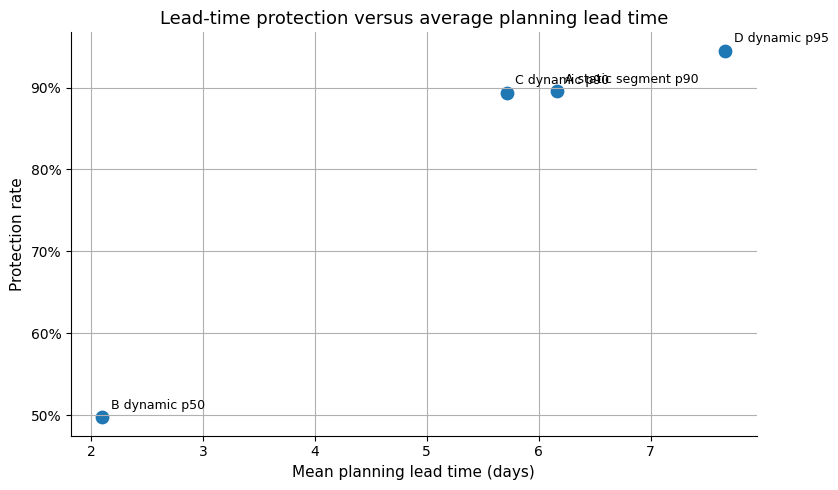

In [6]:
actual_lead_time_d = final_holdout_df[TARGET] / 24


def summarize_policy_leads(policy_frame, actual):
    rows = []
    for policy in policy_frame.columns:
        lead = policy_frame[policy]
        buffer_excess = lead - actual
        rows.append(
            {
                "policy": policy,
                "mean_policy_lead_time_d": float(lead.mean()),
                "protection_rate": float((lead >= actual).mean()),
                "underbuffer_rate": float((lead < actual).mean()),
                "mean_buffer_excess_d": float(buffer_excess.mean()),
            }
        )
    return pd.DataFrame(rows)


policy_summary = summarize_policy_leads(policy_leads, actual_lead_time_d)
display(
    policy_summary.style.format(
        {
            "mean_policy_lead_time_d": "{:,.2f}",
            "protection_rate": "{:.1%}",
            "underbuffer_rate": "{:.1%}",
            "mean_buffer_excess_d": "{:,.2f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.scatter(policy_summary["mean_policy_lead_time_d"], policy_summary["protection_rate"], s=80)
for _, row in policy_summary.iterrows():
    ax.annotate(row["policy"].replace("_", " "), (row["mean_policy_lead_time_d"], row["protection_rate"]), xytext=(6, 6), textcoords="offset points", fontsize=9)
ax.set_title("Lead-time protection versus average planning lead time")
ax.set_xlabel("Mean planning lead time (days)")
ax.set_ylabel("Protection rate")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

## 8. Safety-Stock Simulation — Base Scenario

A lower safety stock is not automatically better. A P50 policy can reduce buffer requirements, but it will naturally leave more long-duration calls underbuffered. The useful comparison is joint: protection rate, underbuffer rate, buffer excess, safety stock, and working-capital proxy.

,policy,mean_policy_lead_time_d,mean_safety_stock_units,proxy_working_capital_brl,protection_rate,underbuffer_rate
0,A_static_segment_p90,6.16,742,"R$ 37,076",89.6%,10.4%
1,B_dynamic_p50,2.10,250,"R$ 12,488",49.7%,50.3%
2,C_dynamic_p90,5.72,709,"R$ 35,456",89.4%,10.6%
3,D_dynamic_p95,7.67,875,"R$ 43,756",94.5%,5.5%


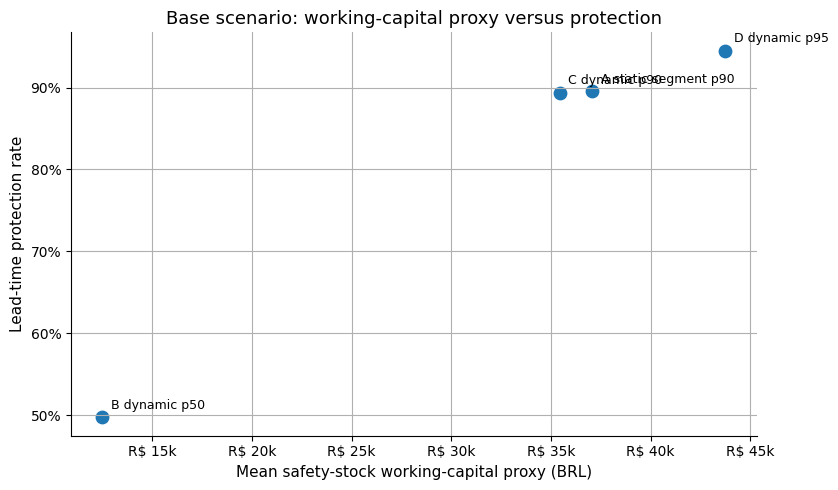

In [7]:
def simulate_safety_stock(policy_frame, actual, scenario_table):
    rows = []
    for _, scenario in scenario_table.iterrows():
        mu = float(scenario["mean_daily_demand_units"])
        sigma = float(scenario["daily_demand_std_units"])
        z = float(scenario["service_factor_z"])
        unit_value = float(scenario["unit_value_brl"])
        for policy in policy_frame.columns:
            lead = policy_frame[policy].clip(lower=0)
            lead_variance = float(lead.var(ddof=1))
            variance_demand_during_lead = sigma**2 * lead + mu**2 * lead_variance
            safety_stock = z * np.sqrt(np.maximum(variance_demand_during_lead, 0))
            rows.append(
                {
                    "scenario": scenario["scenario"],
                    "policy": policy,
                    "mean_daily_demand_units": mu,
                    "daily_demand_std_units": sigma,
                    "service_factor_z": z,
                    "unit_value_brl": unit_value,
                    "lead_time_variance_d2": lead_variance,
                    "mean_policy_lead_time_d": float(lead.mean()),
                    "mean_safety_stock_units": float(safety_stock.mean()),
                    "proxy_working_capital_brl": float(safety_stock.mean() * unit_value),
                    "protection_rate": float((lead >= actual).mean()),
                    "underbuffer_rate": float((lead < actual).mean()),
                    "mean_buffer_excess_d": float((lead - actual).mean()),
                }
            )
    return pd.DataFrame(rows)


safety_stock_results = simulate_safety_stock(policy_leads, actual_lead_time_d, scenarios)
base_results = safety_stock_results[safety_stock_results["scenario"] == "base"].copy()

display(
    base_results[
        [
            "policy",
            "mean_policy_lead_time_d",
            "mean_safety_stock_units",
            "proxy_working_capital_brl",
            "protection_rate",
            "underbuffer_rate",
        ]
    ].style.format(
        {
            "mean_policy_lead_time_d": "{:,.2f}",
            "mean_safety_stock_units": "{:,.0f}",
            "proxy_working_capital_brl": "R$ {:,.0f}",
            "protection_rate": "{:.1%}",
            "underbuffer_rate": "{:.1%}",
        }
    )
)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.scatter(base_results["proxy_working_capital_brl"], base_results["protection_rate"], s=80)
for _, row in base_results.iterrows():
    ax.annotate(row["policy"].replace("_", " "), (row["proxy_working_capital_brl"], row["protection_rate"]), xytext=(6, 6), textcoords="offset points", fontsize=9)
ax.set_title("Base scenario: working-capital proxy versus protection")
ax.set_xlabel("Mean safety-stock working-capital proxy (BRL)")
ax.set_ylabel("Lead-time protection rate")
ax.xaxis.set_major_formatter(lambda x, pos: f"R$ {x/1000:,.0f}k")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

## 9. Sensitivity Analysis

The same policy lead times are evaluated under four illustrative demand/value scenarios. Demand scale changes the safety-stock magnitude, unit value changes the capital proxy linearly, and the service factor changes the safety-stock multiplier. The lead-time policy affects both inventory magnitude and lead-time protection.

Lead-time protection rates do not change across demand scenarios because `protection_rate` depends only on whether `policy_lead_time >= realized_port_stay_duration`. The scenario parameters `mu`, `sigma`, `z`, and unit value affect safety stock and/or the working-capital proxy, but not this lead-time protection calculation. For the same reason, the P90-to-P95 protection increment remains the same across the four inventory scenarios, while its capital consequence changes.

,scenario,policy,mean_safety_stock_units,proxy_working_capital_brl,protection_rate,underbuffer_rate
0,base,A_static_segment_p90,742,"R$ 37,076",89.6%,10.4%
1,base,B_dynamic_p50,250,"R$ 12,488",49.7%,50.3%
2,base,C_dynamic_p90,709,"R$ 35,456",89.4%,10.6%
3,base,D_dynamic_p95,875,"R$ 43,756",94.5%,5.5%
4,low_demand,A_static_segment_p90,372,"R$ 18,615",89.6%,10.4%
5,low_demand,B_dynamic_p50,126,"R$ 6,321",49.7%,50.3%
6,low_demand,C_dynamic_p90,356,"R$ 17,803",89.4%,10.6%
7,low_demand,D_dynamic_p95,439,"R$ 21,959",94.5%,5.5%
8,high_demand,A_static_segment_p90,"1,483","R$ 74,152",89.6%,10.4%
9,high_demand,B_dynamic_p50,500,"R$ 24,977",49.7%,50.3%


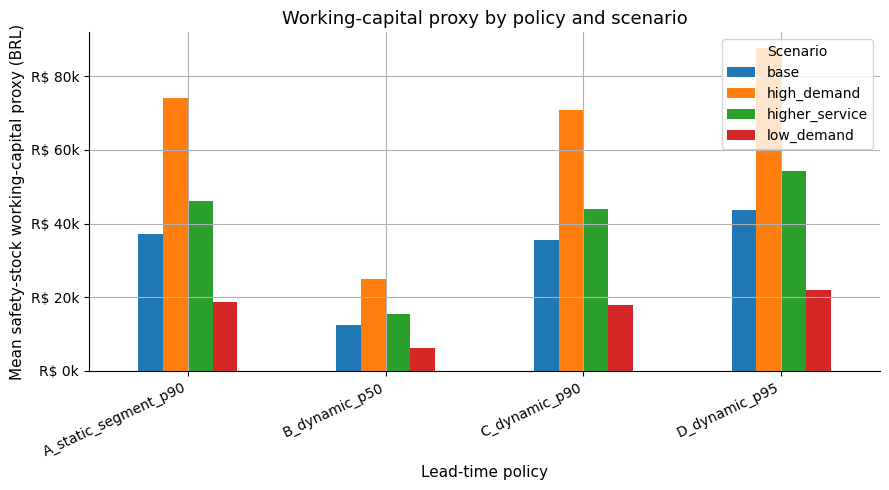

In [8]:
sensitivity_table = safety_stock_results[
    [
        "scenario",
        "policy",
        "mean_safety_stock_units",
        "proxy_working_capital_brl",
        "protection_rate",
        "underbuffer_rate",
    ]
].copy()

display(
    sensitivity_table.style.format(
        {
            "mean_safety_stock_units": "{:,.0f}",
            "proxy_working_capital_brl": "R$ {:,.0f}",
            "protection_rate": "{:.1%}",
            "underbuffer_rate": "{:.1%}",
        }
    )
)

pivot = sensitivity_table.pivot(index="policy", columns="scenario", values="proxy_working_capital_brl")
fig, ax = plt.subplots(figsize=(9, 5))
pivot.loc[policy_leads.columns].plot(kind="bar", ax=ax)
ax.set_title("Working-capital proxy by policy and scenario")
ax.set_xlabel("Lead-time policy")
ax.set_ylabel("Mean safety-stock working-capital proxy (BRL)")
ax.yaxis.set_major_formatter(lambda x, pos: f"R$ {x/1000:,.0f}k")
ax.legend(title="Scenario")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 10. Incremental P90-to-P95 Trade-Off

Moving from dynamic P90 to dynamic P95 usually increases the planning lead time, safety stock, and working-capital proxy. The table below compares that extra buffer with the additional final-test lead-time protection. This is not an ROI calculation.

In [9]:
def incremental_tradeoff(results, lower_policy="C_dynamic_p90", upper_policy="D_dynamic_p95"):
    rows = []
    for scenario, part in results.groupby("scenario"):
        lower = part[part["policy"] == lower_policy].iloc[0]
        upper = part[part["policy"] == upper_policy].iloc[0]
        rows.append(
            {
                "scenario": scenario,
                "from_policy": lower_policy,
                "to_policy": upper_policy,
                "extra_mean_safety_stock_units": float(upper["mean_safety_stock_units"] - lower["mean_safety_stock_units"]),
                "extra_proxy_working_capital_brl": float(upper["proxy_working_capital_brl"] - lower["proxy_working_capital_brl"]),
                "extra_protection_percentage_points": float(100 * (upper["protection_rate"] - lower["protection_rate"])),
                "underbuffer_reduction_percentage_points": float(100 * (lower["underbuffer_rate"] - upper["underbuffer_rate"])),
            }
        )
    return pd.DataFrame(rows)


p90_to_p95 = incremental_tradeoff(safety_stock_results)
display(
    p90_to_p95.style.format(
        {
            "extra_mean_safety_stock_units": "{:,.0f}",
            "extra_proxy_working_capital_brl": "R$ {:,.0f}",
            "extra_protection_percentage_points": "{:,.2f}",
            "underbuffer_reduction_percentage_points": "{:,.2f}",
        }
    )
)

,scenario,from_policy,to_policy,extra_mean_safety_stock_units,extra_proxy_working_capital_brl,extra_protection_percentage_points,underbuffer_reduction_percentage_points
0,base,C_dynamic_p90,D_dynamic_p95,166,"R$ 8,300",5.12,5.12
1,high_demand,C_dynamic_p90,D_dynamic_p95,332,"R$ 16,601",5.12,5.12
2,higher_service,C_dynamic_p90,D_dynamic_p95,206,"R$ 10,313",5.12,5.12
3,low_demand,C_dynamic_p90,D_dynamic_p95,83,"R$ 4,157",5.12,5.12


## 11. Final-Test Business Interpretation

In this illustrative scenario, dynamic P50 carries less inventory but gives lower lead-time protection. Dynamic P90 offers a stronger compromise between protection and inventory, while dynamic P95 increases protection further at a higher safety-stock and working-capital proxy.

A dynamic quantile policy adapts buffer requirements to heterogeneous vessel calls, rather than assigning the same historical segment value to every call in a group. Whether this is economically preferable in a real company cannot be determined from the public dataset alone.

## 12. Limitations

This notebook is intentionally limited:

- Port stay is only one component of end-to-end supply lead time.
- Demand is simulated.
- Demand variance is simulated.
- Unit value is simulated.
- There are no real SKU, order, inventory, or replenishment-policy records.
- No holding cost is modeled.
- No shortage cost is modeled.
- No order quantity is modeled.
- No inventory-position simulation is performed.
- Working capital is a proxy, not an accounting measurement.
- Protection rate is not fill rate.
- The results do not demonstrate realized financial savings.

The scenario is useful for translating uncertainty estimates into planning language, but it should not be read as evidence of actual company inventory performance.

## 13. Conclusions

The three-notebook public series follows a simple progression:

- Notebook 01: Can we predict Brazilian vessel port stay?
- Notebook 02: Can we quantify uncertainty around that prediction?
- Notebook 03: How might that uncertainty inform an illustrative inventory-buffer decision?

The answer to the third question is scenario-based. The public port-call dataset supports lead-time modeling and uncertainty analysis, but it does not contain the business data needed to claim real inventory savings, real working-capital savings, or realized service-level improvements.

Dataset: https://www.kaggle.com/datasets/tiagoalberione/brazilian-port-lead-time-2023-2025

GitHub repository: https://github.com/tiagoalberione/port-leadtime-prediction

In [10]:
elapsed = time.perf_counter() - NOTEBOOK_START
print(f"Notebook runtime measured inside Python: {elapsed:.1f} seconds")

Notebook runtime measured inside Python: 27.1 seconds
